Device: Apple MPS

DATASET INFORMATION
X shape : (5184, 22, 1000)
y shape : (5184,)
Subjects: ['1', '2', '3', '4', '5', '6', '7', '8', '9']
Sessions: ['0train', '1test']
Classes: [0 1 2 3]
Class counts: [1296 1296 1296 1296]
Calibration session = 0train
Test session        = 1test


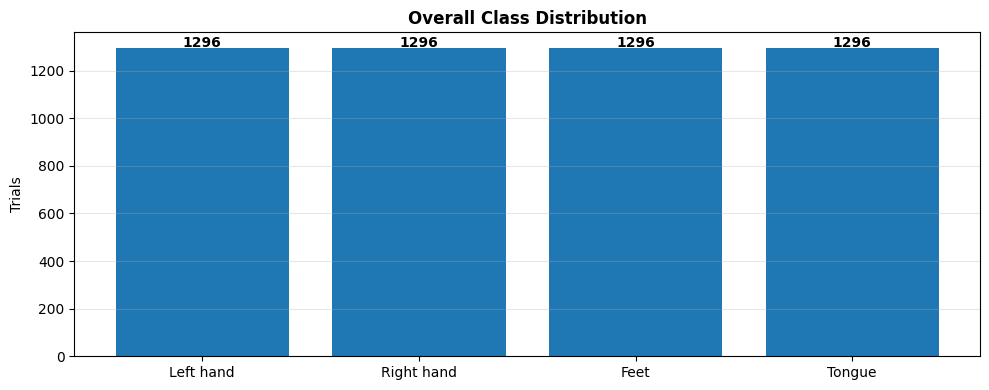


DATASET AUDIT TABLE
Subject Session  Trials  Left hand  Right hand  Feet  Tongue
      1  0train     288         72          72    72      72
      1   1test     288         72          72    72      72
      2  0train     288         72          72    72      72
      2   1test     288         72          72    72      72
      3  0train     288         72          72    72      72
      3   1test     288         72          72    72      72
      4  0train     288         72          72    72      72
      4   1test     288         72          72    72      72
      5  0train     288         72          72    72      72
      5   1test     288         72          72    72      72
      6  0train     288         72          72    72      72
      6   1test     288         72          72    72      72
      7  0train     288         72          72    72      72
      7   1test     288         72          72    72      72
      8  0train     288         72          72    72      72
   

ValueError: operands could not be broadcast together with remapped shapes [original->remapped]: (4,22)->(22,newaxis,4) (288,22,1000)->(288,newaxis,1000,22) 

In [1]:
# ============================================================
# PAPER-STYLE CRNN-DF + FBCSP/LASSO + DUAL-DISCRIMINATOR FBGAN
# SINGLE-CELL JUPYTER NOTEBOOK IMPLEMENTATION
#
# Requires:
#   eeg_bundle.pkl
#
# Expected bundle keys:
#   X_raw, y, subjects, sessions
# Optional:
#   S0, S1
#
# Pipeline:
#   1. Load and validate data
#   2. 1–38 Hz preprocessing
#   3. LOSO split
#   4. Filter-bank CSP
#   5. LASSO sparse selection
#   6. CRNN-DF baseline
#   7. Sparse filter-bank transform
#   8. Class-specific FBGAN
#   9. Raw EEG discriminator D_phi
#  10. Sparse filter-bank discriminator D_psi
#  11. Generate synthetic EEG
#  12. Retrain CRNN-DF with augmentation
#  13. Evaluation and plots
#
# IMPORTANT:
# Start with RUN_DEMO = True and RUN_FULL_LOSO = False.
# Full LOSO with 4 GANs × 9 subjects is computationally expensive.
# ============================================================


# ============================================================
# 0. IMPORTS
# ============================================================

import os
import gc
import time
import copy
import pickle
import random
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import butter, sosfiltfilt, welch
from scipy.linalg import eigh

from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.manifold import TSNE

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torch.utils.data import TensorDataset, DataLoader


# ============================================================
# 1. REPRODUCIBILITY AND DEVICE
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    device = torch.device("cuda")
    print("Device: CUDA")

elif torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Device: Apple MPS")

else:
    device = torch.device("cpu")
    print("Device: CPU")


# ============================================================
# 2. CONFIGURATION
# ============================================================

BUNDLE_PATH = "eeg_bundle.pkl"

FS = 250
N_CH = 22
N_T = 1000
N_CLASSES = 4

CLASSES = [
    "Left hand",
    "Right hand",
    "Feet",
    "Tongue"
]


# ------------------------------------------------------------
# Filter-bank configuration
# ------------------------------------------------------------

BANDS = [
    (1, 4),
    (4, 8),
    (8, 12),
    (12, 16),
    (16, 20),
    (20, 24),
    (24, 28),
    (28, 32),
    (32, 35),
    (35, 38)
]


# ------------------------------------------------------------
# CSP + LASSO
# ------------------------------------------------------------

CSP_PER_CLASS = 4

LASSO_MIN = 8
LASSO_MAX = 64


# ------------------------------------------------------------
# CRNN-DF parameters
# ------------------------------------------------------------

CRNN_EPOCHS = 200

CRNN_WARMUP = 30

CRNN_BATCH = 32

CRNN_LR = 1e-4

LAM_CENTER = 0.10

LAM_INTER = 0.01

CENTER_ALPHA = 0.5

DROPOUT = 0.5


# ------------------------------------------------------------
# GAN parameters
# ------------------------------------------------------------

NOISE_DIM = 1600

GAN_EPOCHS = 300

GAN_BATCH = 16

GAN_LR_G = 2e-4

GAN_LR_D = 2e-4

N_FAKE_PER_CLASS = 750


# ------------------------------------------------------------
# Execution controls
# ------------------------------------------------------------

RUN_DEMO = True

DEMO_SUBJECT = "1"

RUN_FULL_LOSO = False

SHOW_DEMO_PLOTS = True


# ------------------------------------------------------------
# Paper reference values used only for comparison plots
# ------------------------------------------------------------

PAPER_CRNN = {
    "1": 65.51,
    "2": 45.18,
    "3": 78.62,
    "4": 53.58,
    "5": 55.64,
    "6": 56.03,
    "7": 71.28,
    "8": 75.02,
    "9": 70.78
}


PAPER_GAN = {
    "1": 79.60,
    "2": 54.25,
    "3": 83.84,
    "4": 60.93,
    "5": 70.54,
    "6": 62.18,
    "7": 79.94,
    "8": 82.01,
    "9": 81.36
}


# ============================================================
# 3. LOAD DATA
# ============================================================

assert os.path.exists(BUNDLE_PATH), \
    f"{BUNDLE_PATH} not found in current directory."


with open(BUNDLE_PATH, "rb") as f:
    bundle = pickle.load(f)


X_raw = np.asarray(
    bundle["X_raw"],
    dtype=np.float32
)


y = np.asarray(
    bundle["y"],
    dtype=np.int64
)


subjects = np.asarray(
    bundle["subjects"]
).astype(str)


sessions = np.asarray(
    bundle["sessions"]
).astype(str)


unique_sessions = sorted(
    np.unique(sessions)
)


S0 = str(
    bundle.get(
        "S0",
        unique_sessions[0]
    )
)


S1 = str(
    bundle.get(
        "S1",
        unique_sessions[1]
    )
)


print("\n" + "=" * 70)
print("DATASET INFORMATION")
print("=" * 70)

print("X shape :", X_raw.shape)
print("y shape :", y.shape)

print(
    "Subjects:",
    sorted(
        np.unique(subjects),
        key=lambda z: int(z)
    )
)

print("Sessions:", unique_sessions)

print(
    "Classes:",
    np.unique(y)
)

print(
    "Class counts:",
    np.bincount(
        y,
        minlength=N_CLASSES
    )
)

print(
    f"Calibration session = {S0}"
)

print(
    f"Test session        = {S1}"
)


assert X_raw.ndim == 3
assert X_raw.shape[1] == N_CH
assert X_raw.shape[2] == N_T


# ============================================================
# 4. DATASET INFORMATION MAPS
# ============================================================

counts = np.bincount(
    y,
    minlength=N_CLASSES
)


plt.figure(figsize=(10, 4))

plt.bar(
    CLASSES,
    counts
)

plt.title(
    "Overall Class Distribution",
    fontweight="bold"
)

plt.ylabel(
    "Trials"
)

plt.grid(
    axis="y",
    alpha=0.3
)

for i, value in enumerate(counts):

    plt.text(
        i,
        value + 5,
        str(value),
        ha="center",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()


rows = []

for subject in sorted(
    np.unique(subjects),
    key=lambda z: int(z)
):

    for session in unique_sessions:

        mask = (
            (subjects == subject)
            &
            (sessions == session)
        )

        class_counts = np.bincount(
            y[mask],
            minlength=N_CLASSES
        )

        rows.append(
            [
                subject,
                session,
                len(y[mask]),
                *class_counts
            ]
        )


audit_df = pd.DataFrame(
    rows,
    columns=[
        "Subject",
        "Session",
        "Trials",
        *CLASSES
    ]
)


print("\nDATASET AUDIT TABLE")
print(audit_df.to_string(index=False))


# ============================================================
# 5. PREPROCESSING
# ============================================================

def bandpass_np(
    X,
    low,
    high,
    fs=FS,
    order=4
):

    sos = butter(
        order,
        [low, high],
        btype="bandpass",
        fs=fs,
        output="sos"
    )

    filtered = sosfiltfilt(
        sos,
        X,
        axis=-1
    )

    return filtered.astype(
        np.float32
    )


def preprocess(X):

    return bandpass_np(
        X,
        1,
        38
    )


# ============================================================
# 6. LOSO FOLD PREPARATION
# ============================================================

def prepare_fold(test_subject):

    test_subject = str(
        test_subject
    )


    source_mask = (
        subjects != test_subject
    )


    calibration_mask = (
        (subjects == test_subject)
        &
        (sessions == S0)
    )


    test_mask = (
        (subjects == test_subject)
        &
        (sessions == S1)
    )


    X_source = preprocess(
        X_raw[source_mask]
    )


    y_source = y[
        source_mask
    ]


    X_cal = preprocess(
        X_raw[calibration_mask]
    )


    y_cal = y[
        calibration_mask
    ]


    X_test = preprocess(
        X_raw[test_mask]
    )


    y_test = y[
        test_mask
    ]


    # Source-only normalization statistics

    mean = X_source.mean(
        axis=(0, 2),
        keepdims=True
    )


    std = X_source.std(
        axis=(0, 2),
        keepdims=True
    ) + 1e-6


    def normalize(X):

        return (
            (X - mean)
            /
            std
        ).astype(np.float32)


    return (
        normalize(X_source),
        y_source,
        normalize(X_cal),
        y_cal,
        normalize(X_test),
        y_test
    )


# ============================================================
# 7. CSP FUNCTIONS
# ============================================================

def mean_cov(X):

    covariances = []

    for trial in X:

        covariance = (
            trial
            @
            trial.T
        )

        covariance = covariance / (
            np.trace(covariance)
            +
            1e-10
        )

        covariances.append(
            covariance
        )

    return np.mean(
        covariances,
        axis=0
    )


def fit_binary_csp(
    X_positive,
    X_negative,
    n_components=CSP_PER_CLASS
):

    C_positive = mean_cov(
        X_positive
    )


    C_negative = mean_cov(
        X_negative
    )


    eigenvalues, eigenvectors = eigh(

        C_positive,

        C_positive
        +
        C_negative
        +
        1e-8
        *
        np.eye(
            C_positive.shape[0]
        )

    )


    order = np.argsort(
        eigenvalues
    )[::-1]


    eigenvectors = eigenvectors[
        :,
        order
    ]


    n_first = n_components // 2

    n_last = (
        n_components
        -
        n_first
    )


    W = np.concatenate(

        [
            eigenvectors[
                :,
                :n_first
            ],

            eigenvectors[
                :,
                -n_last:
            ]
        ],

        axis=1

    )


    return W.astype(
        np.float32
    )


def csp_logvar(
    X,
    W
):

    projected = np.einsum(
        "ct,ncs->nts",
        W.T,
        X
    )


    variance = np.var(
        projected,
        axis=-1
    )


    variance = variance / (
        variance.sum(
            axis=1,
            keepdims=True
        )
        +
        1e-10
    )


    return np.log(
        variance
        +
        1e-10
    ).astype(
        np.float32
    )


# ============================================================
# 8. FILTER-BANK CSP
# ============================================================

def fit_fbcsp(
    X,
    y_values
):

    all_features = []

    all_filters = []

    metadata = []


    for band_index, (
        low,
        high
    ) in enumerate(BANDS):


        X_band = bandpass_np(
            X,
            low,
            high
        )


        band_features = []


        for class_id in range(
            N_CLASSES
        ):


            positive = X_band[
                y_values == class_id
            ]


            negative = X_band[
                y_values != class_id
            ]


            W = fit_binary_csp(
                positive,
                negative
            )


            features = csp_logvar(
                X_band,
                W
            )


            band_features.append(
                features
            )


            for filter_index in range(
                W.shape[1]
            ):

                all_filters.append(
                    W[
                        :,
                        filter_index
                    ]
                )


                metadata.append(
                    (
                        band_index,
                        class_id,
                        filter_index,
                        low,
                        high
                    )
                )


        all_features.append(

            np.concatenate(
                band_features,
                axis=1
            )

        )


    feature_matrix = np.concatenate(
        all_features,
        axis=1
    )


    filter_matrix = np.stack(
        all_filters,
        axis=1
    ).astype(
        np.float32
    )


    return (
        feature_matrix,
        filter_matrix,
        metadata
    )


# ============================================================
# 9. LASSO SPARSE SELECTION
# ============================================================

def fit_sparse_fbcsp(
    X_cal,
    y_cal
):

    print(
        "    -> FBCSP extraction..."
    )


    features, W_all, metadata = fit_fbcsp(
        X_cal,
        y_cal
    )


    scaler = StandardScaler()


    features_scaled = scaler.fit_transform(
        features
    )


    print(
        "    -> LASSO sparse selection..."
    )


    lasso = LassoCV(
        cv=5,
        max_iter=50000,
        random_state=SEED,
        n_jobs=-1
    )


    lasso.fit(
        features_scaled,
        y_cal.astype(float)
    )


    coefficients = np.abs(
        lasso.coef_
    )


    selected = np.where(
        coefficients > 1e-10
    )[0]


    if len(selected) < LASSO_MIN:

        selected = np.argsort(
            coefficients
        )[::-1][
            :LASSO_MIN
        ]


    if len(selected) > LASSO_MAX:

        ranked = np.argsort(
            coefficients[selected]
        )[::-1]

        selected = selected[
            ranked[
                :LASSO_MAX
            ]
        ]


    selected = np.sort(
        selected
    )


    W_sparse = W_all[
        :,
        selected
    ]


    metadata_sparse = [
        metadata[index]
        for index in selected
    ]


    print(
        f"    total features   : {features.shape[1]}"
    )

    print(
        f"    selected filters : {len(selected)}"
    )


    return {

        "W_sparse":
            W_sparse,

        "meta_sparse":
            metadata_sparse,

        "idx":
            selected,

        "coef":
            coefficients,

        "scaler":
            scaler,

        "lasso":
            lasso
    }


# ============================================================
# 10. CRNN-DF ARCHITECTURE
# ============================================================

class CRNN_DF(nn.Module):

    def __init__(
        self,
        n_filters=32,
        hidden=64
    ):

        super().__init__()


        self.feature_dim = hidden


        self.conv = nn.Conv2d(

            1,

            n_filters,

            kernel_size=(
                N_CH,
                45
            ),

            bias=False

        )


        self.bn = nn.BatchNorm2d(
            n_filters
        )


        self.activation = nn.ReLU()


        self.dropout_conv = nn.Dropout(
            DROPOUT
        )


        self.pool = nn.MaxPool2d(

            kernel_size=(
                1,
                75
            ),

            stride=(
                1,
                10
            )

        )


        self.lstm = nn.LSTM(

            input_size=n_filters,

            hidden_size=hidden,

            num_layers=2,

            batch_first=True,

            dropout=DROPOUT

        )


        self.dropout_feature = nn.Dropout(
            DROPOUT
        )


        self.classifier = nn.Linear(
            hidden,
            N_CLASSES
        )


    def forward(self, x):


        x = x.unsqueeze(1)


        x = self.conv(x)

        x = self.bn(x)

        x = self.activation(x)

        x = self.dropout_conv(x)

        x = self.pool(x)


        x = x.squeeze(2)


        x = x.permute(
            0,
            2,
            1
        )


        output, (
            hidden,
            cell
        ) = self.lstm(x)


        feature = hidden[-1]


        feature = self.dropout_feature(
            feature
        )


        logits = self.classifier(
            feature
        )


        return (
            logits,
            feature
        )


# ============================================================
# 11. DISCRIMINATIVE FEATURE LOSS
# ============================================================

class DFLoss(nn.Module):

    def __init__(
        self,
        feature_dimension=64,
        margin=5.0
    ):

        super().__init__()


        self.margin = margin


        self.register_buffer(

            "centers",

            torch.zeros(
                N_CLASSES,
                feature_dimension
            )

        )


    @torch.no_grad()
    def initialize(
        self,
        model,
        X,
        y_values,
        batch_size=128
    ):

        model.eval()


        all_features = []


        X_tensor = torch.from_numpy(
            X
        ).float()


        for start in range(
            0,
            len(X_tensor),
            batch_size
        ):


            _, features = model(

                X_tensor[
                    start:
                    start + batch_size
                ].to(device)

            )


            all_features.append(
                features.cpu()
            )


        all_features = torch.cat(
            all_features,
            dim=0
        )


        y_tensor = torch.from_numpy(
            y_values
        ).long()


        for class_id in range(
            N_CLASSES
        ):


            mask = (
                y_tensor
                ==
                class_id
            )


            if mask.any():

                self.centers[
                    class_id
                ] = all_features[
                    mask
                ].mean(
                    dim=0
                ).to(device)


        model.train()


    def intra_loss(
        self,
        features,
        labels
    ):


        class_centers = self.centers[
            labels
        ].detach()


        return (

            (
                features
                -
                class_centers
            ) ** 2

        ).sum(
            dim=1
        ).mean()


    def inter_loss(self):


        distances = torch.cdist(

            self.centers,

            self.centers

        )


        mask = ~torch.eye(

            N_CLASSES,

            dtype=torch.bool,

            device=distances.device

        )


        return F.relu(

            self.margin
            -
            distances[mask]

        ).pow(2).mean()


    @torch.no_grad()
    def update(
        self,
        features,
        labels
    ):


        for class_id in range(
            N_CLASSES
        ):


            mask = (
                labels
                ==
                class_id
            )


            if mask.any():


                batch_center = features[
                    mask
                ].detach().mean(
                    dim=0
                )


                self.centers[
                    class_id
                ].mul_(

                    1
                    -
                    CENTER_ALPHA

                ).add_(

                    CENTER_ALPHA
                    *
                    batch_center

                )


# ============================================================
# 12. DATA LOADER
# ============================================================

def create_loader(
    X,
    y_values,
    batch_size=32,
    shuffle=True
):

    dataset = TensorDataset(

        torch.from_numpy(
            X
        ).float(),

        torch.from_numpy(
            y_values
        ).long()

    )


    return DataLoader(

        dataset,

        batch_size=batch_size,

        shuffle=shuffle,

        drop_last=False

    )


# ============================================================
# 13. TRAIN CRNN-DF
# ============================================================

def train_crnn(
    X_train,
    y_train,
    epochs=CRNN_EPOCHS,
    verbose=True
):


    model = CRNN_DF().to(
        device
    )


    df_loss = DFLoss(

        feature_dimension=
            model.feature_dim

    ).to(device)


    optimizer = optim.Adam(

        model.parameters(),

        lr=CRNN_LR

    )


    scheduler = optim.lr_scheduler.CosineAnnealingLR(

        optimizer,

        T_max=epochs,

        eta_min=1e-6

    )


    cross_entropy = nn.CrossEntropyLoss()


    train_loader = create_loader(

        X_train,

        y_train,

        batch_size=CRNN_BATCH,

        shuffle=True

    )


    history = {

        "loss": [],

        "ce": [],

        "center": [],

        "inter": [],

        "acc": []

    }


    for epoch in range(
        1,
        epochs + 1
    ):


        if epoch == CRNN_WARMUP + 1:

            df_loss.initialize(
                model,
                X_train,
                y_train
            )


        model.train()


        epoch_loss = 0.0

        epoch_ce = 0.0

        epoch_center = 0.0

        epoch_inter = 0.0

        correct = 0

        total = 0


        for X_batch, y_batch in train_loader:


            X_batch = X_batch.to(
                device
            )


            y_batch = y_batch.to(
                device
            )


            optimizer.zero_grad()


            logits, features = model(
                X_batch
            )


            loss_ce = cross_entropy(
                logits,
                y_batch
            )


            if epoch > CRNN_WARMUP:


                loss_center = df_loss.intra_loss(
                    features,
                    y_batch
                )


                loss_inter = df_loss.inter_loss()


                loss = (

                    loss_ce

                    +

                    LAM_CENTER
                    *
                    loss_center

                    +

                    LAM_INTER
                    *
                    loss_inter

                )


            else:


                loss_center = torch.tensor(
                    0.0,
                    device=device
                )


                loss_inter = torch.tensor(
                    0.0,
                    device=device
                )


                loss = loss_ce


            loss.backward()


            nn.utils.clip_grad_norm_(
                model.parameters(),
                1.0
            )


            optimizer.step()


            if epoch > CRNN_WARMUP:

                df_loss.update(
                    features,
                    y_batch
                )


            epoch_loss += loss.item()

            epoch_ce += loss_ce.item()

            epoch_center += loss_center.item()

            epoch_inter += loss_inter.item()


            predictions = logits.argmax(
                dim=1
            )


            correct += (
                predictions
                ==
                y_batch
            ).sum().item()


            total += len(
                y_batch
            )


        scheduler.step()


        n_batches = len(
            train_loader
        )


        history["loss"].append(
            epoch_loss / n_batches
        )


        history["ce"].append(
            epoch_ce / n_batches
        )


        history["center"].append(
            epoch_center / n_batches
        )


        history["inter"].append(
            epoch_inter / n_batches
        )


        history["acc"].append(
            100
            *
            correct
            /
            total
        )


        if verbose and (
            epoch == 1
            or
            epoch % 25 == 0
        ):

            print(

                f"    CRNN ep {epoch:3d}/{epochs} | "

                f"loss={history['loss'][-1]:.4f} | "

                f"CE={history['ce'][-1]:.4f} | "

                f"center={history['center'][-1]:.4f} | "

                f"train={history['acc'][-1]:.2f}%"

            )


    return (
        model,
        history
    )


# ============================================================
# 14. PREDICTION
# ============================================================

@torch.no_grad()
def predict(
    model,
    X,
    batch_size=128
):


    model.eval()


    probabilities = []

    all_features = []


    X_tensor = torch.from_numpy(
        X
    ).float()


    for start in range(
        0,
        len(X_tensor),
        batch_size
    ):


        logits, features = model(

            X_tensor[
                start:
                start + batch_size
            ].to(device)

        )


        probabilities.append(

            torch.softmax(
                logits,
                dim=1
            ).cpu().numpy()

        )


        all_features.append(

            features.cpu().numpy()

        )


    return (

        np.vstack(
            probabilities
        ),

        np.vstack(
            all_features
        )

    )


# ============================================================
# 15. DIFFERENTIABLE SPARSE FILTER-BANK TRANSFORM
# ============================================================

class SparseFBTransform(nn.Module):

    def __init__(
        self,
        sparse_pack
    ):

        super().__init__()


        W = sparse_pack[
            "W_sparse"
        ]


        metadata = sparse_pack[
            "meta_sparse"
        ]


        self.register_buffer(

            "W",

            torch.tensor(
                W,
                dtype=torch.float32
            )

        )


        frequencies = torch.fft.rfftfreq(

            N_T,

            d=1.0 / FS

        )


        masks = []


        for item in metadata:


            band_index = item[0]


            low, high = BANDS[
                band_index
            ]


            mask = (

                (frequencies >= low)

                &

                (frequencies < high)

            ).float()


            masks.append(
                mask
            )


        self.register_buffer(

            "masks",

            torch.stack(
                masks
            )

        )


    def forward(self, x):


        spectrum = torch.fft.rfft(

            x,

            dim=-1

        )


        filtered_spectrum = (

            spectrum.unsqueeze(1)

            *

            self.masks[
                None,
                :,
                None,
                :
            ]

        )


        filtered = torch.fft.irfft(

            filtered_spectrum,

            n=N_T,

            dim=-1

        )


        sparse_projection = torch.einsum(

            "ck,bkct->bkt",

            self.W,

            filtered

        )


        return sparse_projection


# ============================================================
# 16. GENERATOR
# ============================================================

class Generator(nn.Module):

    def __init__(self):

        super().__init__()


        self.fc = nn.Linear(

            NOISE_DIM,

            128
            *
            4
            *
            4

        )


        self.net = nn.Sequential(


            nn.ConvTranspose2d(
                128,
                128,
                kernel_size=(3, 15),
                stride=(1, 3),
                padding=(1, 6)
            ),

            nn.BatchNorm2d(128),

            nn.LeakyReLU(
                0.2,
                inplace=True
            ),


            nn.ConvTranspose2d(
                128,
                128,
                kernel_size=(3, 15),
                stride=(1, 3),
                padding=(1, 6)
            ),

            nn.BatchNorm2d(128),

            nn.LeakyReLU(
                0.2,
                inplace=True
            ),


            nn.ConvTranspose2d(
                128,
                64,
                kernel_size=(3, 5),
                stride=(1, 2),
                padding=(1, 2)
            ),

            nn.BatchNorm2d(64),

            nn.LeakyReLU(
                0.2,
                inplace=True
            ),


            nn.ConvTranspose2d(
                64,
                32,
                kernel_size=(4, 5),
                stride=(2, 1),
                padding=(1, 2)
            ),

            nn.BatchNorm2d(32),

            nn.LeakyReLU(
                0.2,
                inplace=True
            ),


            nn.ConvTranspose2d(
                32,
                1,
                kernel_size=(1, 2),
                stride=(1, 1)
            ),

            nn.Tanh()

        )


    def forward(self, z):


        x = self.fc(z)


        x = x.view(
            -1,
            128,
            4,
            4
        )


        x = self.net(x)


        x = F.interpolate(

            x,

            size=(
                N_CH,
                N_T
            ),

            mode="bilinear",

            align_corners=False

        )


        return x.squeeze(1)


# ============================================================
# 17. RAW EEG DISCRIMINATOR D_PHI
# ============================================================

class Dphi(nn.Module):

    def __init__(self):

        super().__init__()


        self.features = nn.Sequential(


            nn.Conv2d(
                1,
                32,
                kernel_size=(3, 15),
                stride=(1, 3),
                padding=(1, 6)
            ),

            nn.LeakyReLU(
                0.2,
                inplace=True
            ),


            nn.Conv2d(
                32,
                64,
                kernel_size=(3, 15),
                stride=(1, 3),
                padding=(1, 6)
            ),

            nn.LeakyReLU(
                0.2,
                inplace=True
            ),


            nn.MaxPool2d(
                kernel_size=(2, 2)
            ),


            nn.Conv2d(
                64,
                128,
                kernel_size=(3, 5),
                stride=(1, 2),
                padding=(1, 2)
            ),

            nn.LeakyReLU(
                0.2,
                inplace=True
            ),


            nn.AdaptiveAvgPool2d(
                (1, 1)
            )

        )


        self.classifier = nn.Linear(
            128,
            1
        )


    def forward(self, x):


        x = x.unsqueeze(1)


        x = self.features(x)


        x = x.flatten(1)


        return self.classifier(x)


# ============================================================
# 18. SPARSE FB DISCRIMINATOR D_PSI
# ============================================================

class Dpsi(nn.Module):

    def __init__(
        self,
        n_sparse
    ):

        super().__init__()


        self.features = nn.Sequential(


            nn.Conv1d(
                n_sparse,
                64,
                kernel_size=15,
                stride=3,
                padding=7
            ),

            nn.LeakyReLU(
                0.2,
                inplace=True
            ),


            nn.Conv1d(
                64,
                128,
                kernel_size=15,
                stride=3,
                padding=7
            ),

            nn.LeakyReLU(
                0.2,
                inplace=True
            ),


            nn.MaxPool1d(
                kernel_size=4
            ),


            nn.Conv1d(
                128,
                128,
                kernel_size=5,
                stride=2,
                padding=2
            ),

            nn.LeakyReLU(
                0.2,
                inplace=True
            ),


            nn.AdaptiveAvgPool1d(
                1
            )

        )


        self.classifier = nn.Linear(
            128,
            1
        )


    def forward(self, x):


        x = self.features(x)


        x = x.squeeze(-1)


        return self.classifier(x)


# ============================================================
# 19. TRAIN ONE CLASS-SPECIFIC FBGAN
# ============================================================

def train_gan_class(
    X_class,
    sparse_pack,
    epochs=GAN_EPOCHS
):


    sparse_transform = SparseFBTransform(
        sparse_pack
    ).to(device)


    generator = Generator().to(
        device
    )


    discriminator_phi = Dphi().to(
        device
    )


    n_sparse = sparse_pack[
        "W_sparse"
    ].shape[1]


    discriminator_psi = Dpsi(
        n_sparse
    ).to(device)


    optimizer_G = optim.Adam(

        generator.parameters(),

        lr=GAN_LR_G,

        betas=(
            0.5,
            0.999
        )

    )


    optimizer_D = optim.Adam(

        list(
            discriminator_phi.parameters()
        )

        +

        list(
            discriminator_psi.parameters()
        ),

        lr=GAN_LR_D,

        betas=(
            0.5,
            0.999
        )

    )


    criterion = nn.BCEWithLogitsLoss()


    dataset = TensorDataset(

        torch.from_numpy(
            X_class
        ).float()

    )


    loader = DataLoader(

        dataset,

        batch_size=min(
            GAN_BATCH,
            len(X_class)
        ),

        shuffle=True,

        drop_last=False

    )


    history = {

        "G": [],

        "D": [],

        "Dphi": [],

        "Dpsi": []

    }


    for epoch in range(
        1,
        epochs + 1
    ):


        total_G = 0.0

        total_D = 0.0

        total_phi = 0.0

        total_psi = 0.0

        batches = 0


        for (real,) in loader:


            real = real.to(
                device
            )


            batch_size = real.size(0)


            real_label = torch.full(

                (
                    batch_size,
                    1
                ),

                0.9,

                device=device

            )


            fake_label = torch.full(

                (
                    batch_size,
                    1
                ),

                0.1,

                device=device

            )


            # =================================================
            # TRAIN DISCRIMINATORS
            # =================================================

            optimizer_D.zero_grad()


            noise = torch.randn(

                batch_size,

                NOISE_DIM,

                device=device

            )


            with torch.no_grad():

                fake = generator(
                    noise
                )


            # Raw EEG path

            loss_phi = (

                criterion(

                    discriminator_phi(
                        real
                    ),

                    real_label

                )

                +

                criterion(

                    discriminator_phi(
                        fake.detach()
                    ),

                    fake_label

                )

            )


            # Sparse filter-bank path

            real_sparse = sparse_transform(
                real
            )


            fake_sparse = sparse_transform(
                fake.detach()
            )


            loss_psi = (

                criterion(

                    discriminator_psi(
                        real_sparse
                    ),

                    real_label

                )

                +

                criterion(

                    discriminator_psi(
                        fake_sparse
                    ),

                    fake_label

                )

            )


            loss_D = (
                loss_phi
                +
                loss_psi
            )


            loss_D.backward()


            optimizer_D.step()


            # =================================================
            # TRAIN GENERATOR
            # =================================================

            optimizer_G.zero_grad()


            noise = torch.randn(

                batch_size,

                NOISE_DIM,

                device=device

            )


            fake = generator(
                noise
            )


            fake_sparse = sparse_transform(
                fake
            )


            loss_G = (

                criterion(

                    discriminator_phi(
                        fake
                    ),

                    real_label

                )

                +

                criterion(

                    discriminator_psi(
                        fake_sparse
                    ),

                    real_label

                )

            )


            loss_G.backward()


            nn.utils.clip_grad_norm_(

                generator.parameters(),

                5.0

            )


            optimizer_G.step()


            total_G += loss_G.item()

            total_D += loss_D.item()

            total_phi += loss_phi.item()

            total_psi += loss_psi.item()

            batches += 1


        history["G"].append(
            total_G / batches
        )


        history["D"].append(
            total_D / batches
        )


        history["Dphi"].append(
            total_phi / batches
        )


        history["Dpsi"].append(
            total_psi / batches
        )


        if (
            epoch == 1
            or
            epoch % 50 == 0
        ):

            print(

                f"        GAN ep {epoch:3d}/{epochs} | "

                f"G={history['G'][-1]:.4f} | "

                f"D={history['D'][-1]:.4f} | "

                f"Phi={history['Dphi'][-1]:.4f} | "

                f"Psi={history['Dpsi'][-1]:.4f}"

            )


    return (
        generator,
        history
    )


# ============================================================
# 20. GENERATE SYNTHETIC EEG
# ============================================================

@torch.no_grad()
def generate_fake(
    generator,
    number_samples
):


    generator.eval()


    generated = []


    batch_size = 64


    for start in range(
        0,
        number_samples,
        batch_size
    ):


        current_batch = min(

            batch_size,

            number_samples
            -
            start

        )


        noise = torch.randn(

            current_batch,

            NOISE_DIM,

            device=device

        )


        fake = generator(
            noise
        )


        generated.append(

            fake.cpu().numpy()

        )


    return np.vstack(
        generated
    ).astype(
        np.float32
    )


# ============================================================
# 21. TRAIN FOUR CLASS-SPECIFIC GANS
# ============================================================

def train_all_gans(
    X_cal,
    y_cal,
    sparse_pack
):


    fake_X_parts = []

    fake_y_parts = []

    histories = {}


    for class_id in range(
        N_CLASSES
    ):


        print(
            "\n"
            +
            "-" * 60
        )


        print(

            f"FBGAN CLASS {class_id}: "

            f"{CLASSES[class_id]}"

        )


        print(
            "-" * 60
        )


        X_class = X_cal[
            y_cal == class_id
        ]


        print(
            f"Real calibration trials: {len(X_class)}"
        )


        generator, history = train_gan_class(

            X_class,

            sparse_pack,

            epochs=GAN_EPOCHS

        )


        fake_X = generate_fake(

            generator,

            N_FAKE_PER_CLASS

        )


        fake_y = np.full(

            N_FAKE_PER_CLASS,

            class_id,

            dtype=np.int64

        )


        fake_X_parts.append(
            fake_X
        )


        fake_y_parts.append(
            fake_y
        )


        histories[
            class_id
        ] = history


        del generator


        gc.collect()


        if torch.cuda.is_available():

            torch.cuda.empty_cache()


    return (

        np.vstack(
            fake_X_parts
        ),

        np.concatenate(
            fake_y_parts
        ),

        histories

    )


# ============================================================
# 22. EEG QUALITY DIAGNOSTICS
# ============================================================

def normalized_covariance(
    X
):


    covariances = []


    for trial in X:


        covariance = (

            trial
            @
            trial.T

        )


        covariance = covariance / (

            np.trace(
                covariance
            )

            +

            1e-10

        )


        covariances.append(
            covariance
        )


    return np.mean(
        covariances,
        axis=0
    )


def quality_plots(
    real,
    fake,
    title
):


    # --------------------------------------------------------
    # Time domain
    # --------------------------------------------------------

    channel_indices = [
        7,
        9,
        11
    ]


    channel_names = [
        "C3",
        "Cz",
        "C4"
    ]


    fig, axes = plt.subplots(

        1,

        3,

        figsize=(15, 4)

    )


    for axis, channel_index, channel_name in zip(

        axes,

        channel_indices,

        channel_names

    ):


        axis.plot(

            real[
                :,
                channel_index
            ].mean(
                axis=0
            ),

            label="Real"

        )


        axis.plot(

            fake[
                :,
                channel_index
            ].mean(
                axis=0
            ),

            label="Generated",

            alpha=0.8

        )


        axis.set_title(
            channel_name
        )


        axis.grid(
            alpha=0.3
        )


    axes[0].legend()


    fig.suptitle(

        title
        +
        " — Time Domain"

    )


    plt.tight_layout()

    plt.show()


    # --------------------------------------------------------
    # PSD
    # --------------------------------------------------------

    freq_real, psd_real = welch(

        real.mean(
            axis=1
        ),

        fs=FS,

        nperseg=256,

        axis=-1

    )


    freq_fake, psd_fake = welch(

        fake.mean(
            axis=1
        ),

        fs=FS,

        nperseg=256,

        axis=-1

    )


    frequency_mask = (

        (freq_real >= 1)

        &

        (freq_real <= 38)

    )


    plt.figure(
        figsize=(10, 4)
    )


    plt.semilogy(

        freq_real[
            frequency_mask
        ],

        psd_real.mean(
            axis=0
        )[
            frequency_mask
        ],

        label="Real"

    )


    plt.semilogy(

        freq_fake[
            frequency_mask
        ],

        psd_fake.mean(
            axis=0
        )[
            frequency_mask
        ],

        label="Generated"

    )


    plt.title(
        title
        +
        " — PSD Comparison"
    )


    plt.xlabel(
        "Frequency (Hz)"
    )


    plt.ylabel(
        "PSD"
    )


    plt.grid(
        alpha=0.3
    )


    plt.legend()


    plt.tight_layout()

    plt.show()


    # --------------------------------------------------------
    # Covariance maps
    # --------------------------------------------------------

    covariance_real = normalized_covariance(
        real
    )


    covariance_fake = normalized_covariance(
        fake
    )


    fig, axes = plt.subplots(

        1,

        2,

        figsize=(11, 4)

    )


    image = axes[0].imshow(
        covariance_real
    )


    axes[0].set_title(
        "Real Covariance"
    )


    fig.colorbar(
        image,
        ax=axes[0],
        fraction=0.046
    )


    image = axes[1].imshow(
        covariance_fake
    )


    axes[1].set_title(
        "Generated Covariance"
    )


    fig.colorbar(
        image,
        ax=axes[1],
        fraction=0.046
    )


    plt.tight_layout()

    plt.show()


    covariance_correlation = np.corrcoef(

        covariance_real.ravel(),

        covariance_fake.ravel()

    )[0, 1]


    print(

        "Covariance correlation:",

        f"{covariance_correlation:.4f}"

    )


# ============================================================
# 23. RUN ONE LOSO FOLD
# ============================================================

def run_fold(
    test_subject,
    plots=False
):


    start_time = time.time()


    print(
        "\n"
        +
        "=" * 70
    )


    print(
        f"TEST SUBJECT A{test_subject}"
    )


    print(
        "=" * 70
    )


    (
        X_source,
        y_source,
        X_cal,
        y_cal,
        X_test,
        y_test

    ) = prepare_fold(
        test_subject
    )


    print(
        "Source      :",
        X_source.shape
    )


    print(
        "Calibration :",
        X_cal.shape
    )


    print(
        "Test        :",
        X_test.shape
    )


    # ========================================================
    # FBCSP + LASSO
    # ========================================================

    sparse_pack = fit_sparse_fbcsp(

        X_cal,

        y_cal

    )


    print(

        "Sparse filter count:",

        len(
            sparse_pack["idx"]
        )

    )


    # ========================================================
    # BASELINE CRNN-DF
    # ========================================================

    print(
        "\n[1/3] TRAINING CRNN-DF BASELINE"
    )


    baseline_model, baseline_history = train_crnn(

        X_source,

        y_source,

        verbose=True

    )


    baseline_probability, baseline_features = predict(

        baseline_model,

        X_test

    )


    baseline_prediction = baseline_probability.argmax(
        axis=1
    )


    baseline_accuracy = (

        accuracy_score(

            y_test,

            baseline_prediction

        )

        *

        100

    )


    print(

        f"\nBaseline CRNN-DF accuracy: "

        f"{baseline_accuracy:.2f}%"

    )


    # ========================================================
    # TRAIN FBGAN
    # ========================================================

    print(
        "\n[2/3] TRAINING CLASS-SPECIFIC FBGAN"
    )


    fake_X, fake_y, gan_histories = train_all_gans(

        X_cal,

        y_cal,

        sparse_pack

    )


    print(

        "\nGenerated EEG shape:",

        fake_X.shape

    )


    print(

        "Generated labels shape:",

        fake_y.shape

    )


    # ========================================================
    # AUGMENTED TRAINING
    # ========================================================

    print(
        "\n[3/3] TRAINING AUGMENTED CRNN-DF"
    )


    X_augmented = np.concatenate(

        [
            X_source,
            fake_X
        ],

        axis=0

    )


    y_augmented = np.concatenate(

        [
            y_source,
            fake_y
        ],

        axis=0

    )


    print(

        "Augmented training set:",

        X_augmented.shape

    )


    augmented_model, augmented_history = train_crnn(

        X_augmented,

        y_augmented,

        verbose=True

    )


    augmented_probability, augmented_features = predict(

        augmented_model,

        X_test

    )


    augmented_prediction = augmented_probability.argmax(
        axis=1
    )


    augmented_accuracy = (

        accuracy_score(

            y_test,

            augmented_prediction

        )

        *

        100

    )


    print(
        "\n"
        +
        "-" * 60
    )


    print(

        f"A{test_subject} Baseline : "

        f"{baseline_accuracy:.2f}%"

    )


    print(

        f"A{test_subject} + FBGAN : "

        f"{augmented_accuracy:.2f}%"

    )


    print(

        f"GAN gain             : "

        f"{augmented_accuracy - baseline_accuracy:+.2f}%"

    )


    if str(test_subject) in PAPER_CRNN:

        print(

            f"Paper CRNN-DF        : "

            f"{PAPER_CRNN[str(test_subject)]:.2f}%"

        )


        print(

            f"Paper +GAN           : "

            f"{PAPER_GAN[str(test_subject)]:.2f}%"

        )


    print(
        "-" * 60
    )


    # ========================================================
    # PLOTS
    # ========================================================

    if plots:


        # ----------------------------------------------------
        # CRNN training loss
        # ----------------------------------------------------

        plt.figure(
            figsize=(11, 4)
        )


        plt.plot(

            baseline_history[
                "loss"
            ],

            label="Baseline"

        )


        plt.plot(

            augmented_history[
                "loss"
            ],

            label="FBGAN Augmented"

        )


        plt.axvline(

            CRNN_WARMUP,

            linestyle="--",

            label="DF Loss Start"

        )


        plt.title(

            f"A{test_subject} CRNN-DF Training Loss"

        )


        plt.xlabel(
            "Epoch"
        )


        plt.ylabel(
            "Loss"
        )


        plt.grid(
            alpha=0.3
        )


        plt.legend()


        plt.tight_layout()

        plt.show()


        # ----------------------------------------------------
        # Training accuracy
        # ----------------------------------------------------

        plt.figure(
            figsize=(11, 4)
        )


        plt.plot(

            baseline_history[
                "acc"
            ],

            label="Baseline"

        )


        plt.plot(

            augmented_history[
                "acc"
            ],

            label="FBGAN Augmented"

        )


        plt.title(

            f"A{test_subject} Training Accuracy"

        )


        plt.xlabel(
            "Epoch"
        )


        plt.ylabel(
            "Accuracy (%)"
        )


        plt.grid(
            alpha=0.3
        )


        plt.legend()


        plt.tight_layout()

        plt.show()


        # ----------------------------------------------------
        # GAN losses
        # ----------------------------------------------------

        plt.figure(
            figsize=(11, 5)
        )


        for class_id in range(
            N_CLASSES
        ):


            plt.plot(

                gan_histories[
                    class_id
                ][
                    "G"
                ],

                label=(
                    "G "
                    +
                    CLASSES[
                        class_id
                    ]
                )

            )


        plt.title(

            f"A{test_subject} Generator Losses"

        )


        plt.xlabel(
            "Epoch"
        )


        plt.ylabel(
            "Generator Loss"
        )


        plt.grid(
            alpha=0.3
        )


        plt.legend()


        plt.tight_layout()

        plt.show()


        # ----------------------------------------------------
        # EEG quality diagnostic
        # ----------------------------------------------------

        quality_plots(

            X_cal[
                y_cal == 0
            ],

            fake_X[
                fake_y == 0
            ],

            f"A{test_subject} — {CLASSES[0]}"

        )


        # ----------------------------------------------------
        # t-SNE
        # ----------------------------------------------------

        print(
            "Computing t-SNE..."
        )


        embedding = TSNE(

            n_components=2,

            perplexity=30,

            random_state=SEED,

            init="pca"

        ).fit_transform(

            augmented_features

        )


        plt.figure(
            figsize=(8, 6)
        )


        for class_id in range(
            N_CLASSES
        ):


            mask = (
                y_test
                ==
                class_id
            )


            plt.scatter(

                embedding[
                    mask,
                    0
                ],

                embedding[
                    mask,
                    1
                ],

                s=15,

                alpha=0.65,

                label=CLASSES[
                    class_id
                ]

            )


        plt.title(

            f"A{test_subject} CRNN-DF Feature t-SNE"

        )


        plt.legend()


        plt.tight_layout()

        plt.show()


        # ----------------------------------------------------
        # Confusion matrix
        # ----------------------------------------------------

        cm = confusion_matrix(

            y_test,

            augmented_prediction,

            normalize="true"

        ) * 100


        plt.figure(
            figsize=(6, 5)
        )


        image = plt.imshow(

            cm,

            vmin=0,

            vmax=100

        )


        plt.colorbar(
            image,
            label="Accuracy (%)"
        )


        plt.xticks(

            range(N_CLASSES),

            CLASSES,

            rotation=30,

            ha="right"

        )


        plt.yticks(

            range(N_CLASSES),

            CLASSES

        )


        plt.title(

            f"A{test_subject} FBGAN Confusion Matrix"

        )


        for i in range(
            N_CLASSES
        ):

            for j in range(
                N_CLASSES
            ):

                plt.text(

                    j,

                    i,

                    f"{cm[i, j]:.0f}",

                    ha="center",

                    va="center"

                )


        plt.tight_layout()

        plt.show()


    elapsed_minutes = (

        time.time()

        -

        start_time

    ) / 60.0


    return {

        "baseline_acc":
            baseline_accuracy,

        "aug_acc":
            augmented_accuracy,

        "baseline_pred":
            baseline_prediction,

        "aug_pred":
            augmented_prediction,

        "y_true":
            y_test,

        "sparse_count":
            len(
                sparse_pack["idx"]
            ),

        "elapsed_min":
            elapsed_minutes

    }


# ============================================================
# 24. SUBJECT 1 DEMONSTRATION
# ============================================================

demo_result = None


if RUN_DEMO:


    print(
        "\n"
        +
        "#" * 70
    )


    print(
        "STARTING DEMONSTRATION FOLD"
    )


    print(
        "#" * 70
    )


    demo_result = run_fold(

        DEMO_SUBJECT,

        plots=SHOW_DEMO_PLOTS

    )


    print(
        "\nDEMO RESULT"
    )


    print(

        f"Subject A{DEMO_SUBJECT}"

    )


    print(

        f"Baseline : "

        f"{demo_result['baseline_acc']:.2f}%"

    )


    print(

        f"+ FBGAN  : "

        f"{demo_result['aug_acc']:.2f}%"

    )


    print(

        f"Paper baseline : "

        f"{PAPER_CRNN[DEMO_SUBJECT]:.2f}%"

    )


    print(

        f"Paper +GAN     : "

        f"{PAPER_GAN[DEMO_SUBJECT]:.2f}%"

    )


# ============================================================
# 25. FULL LOSO EVALUATION
# ============================================================

results = {}


if RUN_FULL_LOSO:


    full_start = time.time()


    subject_list = sorted(

        np.unique(subjects),

        key=lambda z: int(z)

    )


    for subject in subject_list:


        results[
            subject
        ] = run_fold(

            subject,

            plots=False

        )


        gc.collect()


        if torch.cuda.is_available():

            torch.cuda.empty_cache()


    # ========================================================
    # FINAL NUMERICAL RESULTS
    # ========================================================

    print(
        "\n"
        +
        "=" * 75
    )


    print(
        "FINAL PAPER REPLICATION RESULTS"
    )


    print(
        "=" * 75
    )


    for subject in subject_list:


        result = results[
            subject
        ]


        print(

            f"A{subject}: "

            f"CRNN-DF={result['baseline_acc']:.2f}% | "

            f"+FBGAN={result['aug_acc']:.2f}% | "

            f"Paper +GAN={PAPER_GAN[subject]:.2f}%"

        )


    baseline_values = np.array(

        [
            results[
                subject
            ][
                "baseline_acc"
            ]

            for subject in subject_list
        ]

    )


    augmented_values = np.array(

        [
            results[
                subject
            ][
                "aug_acc"
            ]

            for subject in subject_list
        ]

    )


    print(
        "\n"
        +
        "-" * 75
    )


    print(

        f"CRNN-DF mean ± std : "

        f"{baseline_values.mean():.2f} "

        f"± "

        f"{baseline_values.std():.2f}%"

    )


    print(

        f"+FBGAN mean ± std  : "

        f"{augmented_values.mean():.2f} "

        f"± "

        f"{augmented_values.std():.2f}%"

    )


    print(
        "Paper CRNN-DF       : 63.52 ± 10.70%"
    )


    print(
        "Paper + FBGAN       : 72.74 ± 10.44%"
    )


    print(

        f"Gap to paper +GAN   : "

        f"{72.74 - augmented_values.mean():+.2f}%"

    )


    print(
        "-" * 75
    )


    # ========================================================
    # SUBJECT-WISE COMPARISON GRAPH
    # ========================================================

    x = np.arange(
        len(subject_list)
    )


    width = 0.20


    plt.figure(
        figsize=(16, 6)
    )


    plt.bar(

        x - 1.5 * width,

        [
            results[s][
                "baseline_acc"
            ]

            for s in subject_list
        ],

        width,

        label="Our CRNN-DF"

    )


    plt.bar(

        x - 0.5 * width,

        [
            results[s][
                "aug_acc"
            ]

            for s in subject_list
        ],

        width,

        label="Our +FBGAN"

    )


    plt.bar(

        x + 0.5 * width,

        [
            PAPER_CRNN[s]

            for s in subject_list
        ],

        width,

        label="Paper CRNN-DF"

    )


    plt.bar(

        x + 1.5 * width,

        [
            PAPER_GAN[s]

            for s in subject_list
        ],

        width,

        label="Paper +FBGAN"

    )


    plt.xticks(

        x,

        [
            f"A{s}"

            for s in subject_list
        ]

    )


    plt.ylabel(
        "Accuracy (%)"
    )


    plt.title(

        "Subject-wise Replication vs Paper",

        fontweight="bold"

    )


    plt.grid(
        axis="y",
        alpha=0.3
    )


    plt.legend(
        ncol=2
    )


    plt.tight_layout()

    plt.show()


    # ========================================================
    # AGGREGATE CONFUSION MATRIX
    # ========================================================

    all_true = np.concatenate(

        [
            results[s][
                "y_true"
            ]

            for s in subject_list
        ]

    )


    all_augmented_prediction = np.concatenate(

        [
            results[s][
                "aug_pred"
            ]

            for s in subject_list
        ]

    )


    cm = confusion_matrix(

        all_true,

        all_augmented_prediction,

        normalize="true"

    ) * 100


    plt.figure(
        figsize=(7, 6)
    )


    image = plt.imshow(

        cm,

        vmin=0,

        vmax=100

    )


    plt.colorbar(
        image,
        label="Accuracy (%)"
    )


    plt.xticks(

        range(N_CLASSES),

        CLASSES,

        rotation=30,

        ha="right"

    )


    plt.yticks(

        range(N_CLASSES),

        CLASSES

    )


    plt.title(

        "Aggregate Confusion Matrix — CRNN-DF + FBGAN"

    )


    for i in range(
        N_CLASSES
    ):

        for j in range(
            N_CLASSES
        ):

            plt.text(

                j,

                i,

                f"{cm[i, j]:.0f}",

                ha="center",

                va="center"

            )


    plt.tight_layout()

    plt.show()


    # ========================================================
    # PER-SUBJECT PER-CLASS INFORMATION MAP
    # ========================================================

    per_class_accuracy = np.zeros(

        (
            len(subject_list),
            N_CLASSES
        )

    )


    for subject_index, subject in enumerate(
        subject_list
    ):


        true_labels = results[
            subject
        ][
            "y_true"
        ]


        predictions = results[
            subject
        ][
            "aug_pred"
        ]


        for class_id in range(
            N_CLASSES
        ):


            mask = (
                true_labels
                ==
                class_id
            )


            if mask.sum() > 0:

                per_class_accuracy[
                    subject_index,
                    class_id
                ] = (

                    predictions[
                        mask
                    ]

                    ==

                    class_id

                ).mean() * 100


    plt.figure(
        figsize=(9, 6)
    )


    image = plt.imshow(

        per_class_accuracy,

        vmin=0,

        vmax=100,

        aspect="auto"

    )


    plt.colorbar(
        image,
        label="Accuracy (%)"
    )


    plt.xticks(

        range(N_CLASSES),

        CLASSES,

        rotation=30,

        ha="right"

    )


    plt.yticks(

        range(
            len(subject_list)
        ),

        [
            f"A{s}"

            for s in subject_list
        ]

    )


    plt.title(

        "Per-subject Per-class Accuracy Map"

    )


    for i in range(
        len(subject_list)
    ):

        for j in range(
            N_CLASSES
        ):

            plt.text(

                j,

                i,

                f"{per_class_accuracy[i, j]:.0f}",

                ha="center",

                va="center"

            )


    plt.tight_layout()

    plt.show()


    # ========================================================
    # GAN GAIN GRAPH
    # ========================================================

    gains = [

        results[s][
            "aug_acc"
        ]

        -

        results[s][
            "baseline_acc"
        ]

        for s in subject_list

    ]


    plt.figure(
        figsize=(11, 4)
    )


    plt.bar(

        [
            f"A{s}"

            for s in subject_list
        ],

        gains

    )


    plt.axhline(

        0,

        linestyle="--"

    )


    plt.title(

        "FBGAN Augmentation Gain by Subject"

    )


    plt.ylabel(

        "Accuracy Gain (percentage points)"

    )


    plt.grid(

        axis="y",

        alpha=0.3

    )


    plt.tight_layout()

    plt.show()


    # ========================================================
    # SAVE RESULTS
    # ========================================================

    bundle[
        "paper_faithful_results"
    ] = results


    bundle[
        "paper_faithful_baseline_mean"
    ] = float(
        baseline_values.mean()
    )


    bundle[
        "paper_faithful_fbgan_mean"
    ] = float(
        augmented_values.mean()
    )


    with open(
        BUNDLE_PATH,
        "wb"
    ) as f:

        pickle.dump(
            bundle,
            f
        )


    with open(
        "paper_faithful_results.pkl",
        "wb"
    ) as f:

        pickle.dump(
            results,
            f
        )


    total_minutes = (

        time.time()

        -

        full_start

    ) / 60


    print(
        "\nResults saved."
    )


    print(

        f"Total runtime: "

        f"{total_minutes:.1f} minutes"

    )


print(
    "\n"
    +
    "=" * 70
)


print(
    "EXECUTION FINISHED"
)


print(
    "=" * 70
)


print(
    "\nFor complete A1–A9 LOSO evaluation:"
)


print(
    "set RUN_FULL_LOSO = True near the top and rerun the cell."
)